In [3]:
import pandas as pd  
import numpy as np 
import plotly.express as px
import matplotlib as plt
pd.set_option("display.max_columns", None)

df = pd.read_csv('insurance claims data.csv')

In [4]:
def balance_class_probabilistic(df, target_col='claim_status'):
    
    df = df.copy()
    
    # Separate classes
    df_0 = df[df[target_col] == 0]
    df_1 = df[df[target_col] == 1]
    
    # Count needed samples
    n_to_generate = len(df_0) - len(df_1)
    
    # Split column types
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove(target_col)
    
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    
    # ---- NUMERIC: Probabilistic Gaussian Modeling ----
    mean = df_1[numeric_cols].mean().values
    cov = np.cov(df_1[numeric_cols].values.T)
    
    synthetic_numeric = np.random.multivariate_normal(mean, cov, n_to_generate)
    synthetic_numeric = pd.DataFrame(synthetic_numeric, columns=numeric_cols)
    
    # Optional: prevent unrealistic negatives
    synthetic_numeric = synthetic_numeric.clip(lower=0)
    
    # ---- CATEGORICAL: Probabilistic Sampling ----
    synthetic_categorical = pd.DataFrame()
    
    for col in categorical_cols:
        probs = df_1[col].value_counts(normalize=True)
        synthetic_categorical[col] = np.random.choice(
            probs.index, 
            size=n_to_generate, 
            p=probs.values
        )
    
    # ---- Combine ----
    synthetic_df = pd.concat([synthetic_numeric, synthetic_categorical], axis=1)
    
    # Add target
    synthetic_df[target_col] = 1
    
    # Match column order
    synthetic_df = synthetic_df[df.columns]
    
    # ---- Final Balanced Dataset ----
    df_balanced = pd.concat([df, synthetic_df], axis=0).reset_index(drop=True)
    
    return df_balanced, synthetic_df

df, synthetic_class1 = balance_class_probabilistic(df)

print(df['claim_status'].value_counts())

claim_status
0    54844
1    54844
Name: count, dtype: int64


In [5]:
def preprocess_data(df):
    df.drop('Unnamed: 0', axis = 1, inplace=True)
    df['torque_nm'] = df['max_torque'].str.extract(r'(\d+\.?\d*)Nm').astype(float)
    df['torque_rpm'] = df['max_torque'].str.extract(r'@(\d+)rpm').astype(float)
    
    # Extract Power (bhp and RPM)
    df['power_bhp'] = df['max_power'].str.extract(r'(\d+\.?\d*)bhp').astype(float)
    df['power_rpm'] = df['max_power'].str.extract(r'@(\d+)rpm').astype(float)

    df.drop(['max_torque', 'max_power'], axis=1, inplace=True)
    
    return df

def feature_eng(df):
    # Power-to-weight ratio (very useful in insurance risk modeling)
    df['power_to_weight'] = df['power_bhp'] / df['gross_weight']

    # Torque per liter (engine efficiency indicator)
    df['torque_per_liter'] = df['torque_nm'] / (df['displacement'] / 1000)

    # RPM difference (how peaky the engine is)
    df['rpm_diff'] = df['power_rpm'] - df['torque_rpm']

    return df


def overview(df):
    return print(df.shape), print(df.info()), print(df[["fuel_type", "max_power", "max_torque", "engine_type"]].nunique()), print(df[["fuel_type", "max_power", "max_torque", "engine_type"]].isnull().sum()),print(df.nunique()), print(df.describe()), print(df['claim_status'].value_counts()), (px.bar(df['claim_status'].value_counts().reset_index(), x='claim_status', y='count').show())

overview(df)   

df = preprocess_data(df)
df = feature_eng(df)

(109688, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109688 entries, 0 to 109687
Data columns (total 41 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Unnamed: 0                        109688 non-null  object 
 1   subscription_length               109688 non-null  float64
 2   vehicle_age                       109688 non-null  float64
 3   customer_age                      109688 non-null  float64
 4   region_code                       109688 non-null  object 
 5   region_density                    109688 non-null  float64
 6   segment                           109688 non-null  object 
 7   model                             109688 non-null  object 
 8   fuel_type                         109688 non-null  object 
 9   max_torque                        109688 non-null  object 
 10  max_power                         109688 non-null  object 
 11  engine_type                       10968

In [6]:
# ===============================
# 1. ACTIONABLE RISK SEGMENTS
# ===============================

def identify_actionable_risk(df):
    insights = []

    # A. Safety Risk
    safety_cols = [
        'is_esc', 'is_tpms', 'is_parking_sensors',
        'is_parking_camera', 'is_brake_assist'
    ]

    for col in safety_cols:
        risk = df.groupby(col)['claim_status'].mean()
        insights.append({
            'feature': col,
            'risk_no': risk.get('No', np.nan),
            'risk_yes': risk.get('Yes', np.nan),
            'impact': risk.get('No', 0) - risk.get('Yes', 0),
            'action': 'Enable/Install safety feature'
        })

    # B. Vehicle Performance Risk
    perf_risk = df.groupby(pd.qcut(df['power_to_weight'], 4))['claim_status'].mean()
    
    insights.append({
        'feature': 'power_to_weight',
        'risk_trend': perf_risk.to_dict(),
        'action': 'Telematics-based pricing'
    })

    # C. Subscription Risk
    sub_risk = df.groupby(pd.cut(df['subscription_length'], bins=[0,6,12,24,36]))['claim_status'].mean()

    insights.append({
        'feature': 'subscription_length',
        'risk_trend': sub_risk.to_dict(),
        'action': 'Early onboarding engagement'
    })

    return pd.DataFrame(insights)

risk_segments = identify_actionable_risk(df)

print("\n=== ACTIONABLE RISK SEGMENTS ===")
print(risk_segments)

# ===============================
# 2. TIMING ANALYSIS
# ===============================

def timing_analysis(df):
    
    timing_df = df.copy()

    # Create lifecycle buckets
    timing_df['lifecycle_stage'] = pd.cut(
        timing_df['subscription_length'],
        bins=[0,3,6,12,24,36],
        labels=['0-3M','3-6M','6-12M','12-24M','24M+']
    )

    timing_risk = timing_df.groupby('lifecycle_stage')['claim_status'].mean().reset_index()

    return timing_risk

timing_df = timing_analysis(df)

print("\n=== TIMING RISK ANALYSIS ===")
print(timing_df)

# ===============================
# 3. ROI ANALYSIS
# ===============================

def roi_analysis(df):
    
    roi_results = []

    # Segment A: High performance vehicles
    high_perf = df[df['power_to_weight'] > df['power_to_weight'].median()]
    low_perf = df[df['power_to_weight'] <= df['power_to_weight'].median()]

    risk_diff = high_perf['claim_status'].mean() - low_perf['claim_status'].mean()

    roi_results.append({
        'segment': 'High Performance Vehicles',
        'intervention': 'Telematics',
        'cost_per_customer': 50,
        'expected_claim_reduction': risk_diff,
        'estimated_savings': risk_diff * 1000,
        'roi': (risk_diff * 1000 - 50)
    })

    # Segment B: Low safety vehicles
    low_safety = df[df['ncap_rating'] <= 2]
    high_safety = df[df['ncap_rating'] > 2]

    risk_diff = low_safety['claim_status'].mean() - high_safety['claim_status'].mean()

    roi_results.append({
        'segment': 'Low Safety Vehicles',
        'intervention': 'Safety Upgrade Program',
        'cost_per_customer': 75,
        'expected_claim_reduction': risk_diff,
        'estimated_savings': risk_diff * 1200,
        'roi': (risk_diff * 1200 - 75)
    })

    # Segment C: New Customers
    new_customers = df[df['subscription_length'] <= 6]
    old_customers = df[df['subscription_length'] > 6]

    risk_diff = new_customers['claim_status'].mean() - old_customers['claim_status'].mean()

    roi_results.append({
        'segment': 'New Customers',
        'intervention': 'Onboarding + Education',
        'cost_per_customer': 30,
        'expected_claim_reduction': risk_diff,
        'estimated_savings': risk_diff * 800,
        'roi': (risk_diff * 800 - 30)
    })

    return pd.DataFrame(roi_results)

roi_df = roi_analysis(df)

print("\n=== ROI ANALYSIS ===")
print(roi_df)

# ===============================
# BONUS: TOP HIGH-RISK CUSTOMERS
# ===============================

def get_high_risk_customers(df):
    
    df = df.copy()

    # Simple risk score
    df['risk_score'] = (
        df['power_to_weight'] * 0.3 +
        (5 - df['ncap_rating']) * 0.3 +
        (1 / (df['subscription_length'] + 1)) * 0.4
    )

    return df.sort_values(by='risk_score', ascending=False).head(20)

top_risk_customers = get_high_risk_customers(df)

print("\n=== TOP 20 HIGH RISK CUSTOMERS ===")
print(top_risk_customers[['risk_score', 'power_to_weight', 'ncap_rating', 'subscription_length']])

C:\Users\Predator\AppData\Local\Temp\ipykernel_34236\2060494519.py:25: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\Predator\AppData\Local\Temp\ipykernel_34236\2060494519.py:34: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\Predator\AppData\Local\Temp\ipykernel_34236\2060494519.py:64: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.




=== ACTIONABLE RISK SEGMENTS ===
               feature   risk_no  risk_yes    impact  \
0               is_esc  0.497859  0.504621 -0.006763   
1              is_tpms  0.499532  0.501482 -0.001950   
2   is_parking_sensors  0.448267  0.501993 -0.053726   
3    is_parking_camera  0.501663  0.497385  0.004278   
4      is_brake_assist  0.487446  0.509911 -0.022465   
5      power_to_weight       NaN       NaN       NaN   
6  subscription_length       NaN       NaN       NaN   

                          action  \
0  Enable/Install safety feature   
1  Enable/Install safety feature   
2  Enable/Install safety feature   
3  Enable/Install safety feature   
4  Enable/Install safety feature   
5       Telematics-based pricing   
6    Early onboarding engagement   

                                          risk_trend  
0                                                NaN  
1                                                NaN  
2                                                NaN  
3       

**Imbalance Data** 

**Claim Status** - *No claim* is significatly more the *Claim*

**Problem**

1. Bias 
2. Metrics are not reliable such as accuary (If the model is dumb because its data is biased, then accuracy is a wrong metric. )

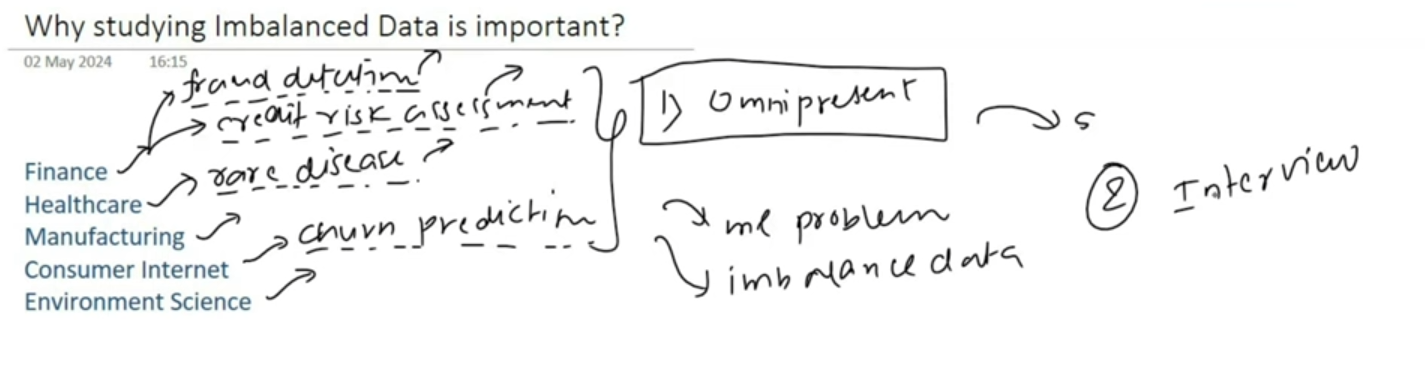

**1st Undersampling (using randam sampling)** method is random sampling using imbalance learning liberary 

**2nd oversampling (using random sampling)** method is duplication random sampling using imbalance learning liberary 

**3nd SMOTE Synthatic minority oversampling technique** generate new data points (uses interpolation)

**4th Balance Random Forest Classification - Esemble based sampling** creating subset from the original dataset which holds imbalance data and in the subset they hold equal data which is derived from original data though random sampling 

**5th cost sensitive learning** 

In [4]:
for i in df.columns:
    print(f"{i}: {df[i].unique()} unique values")
    print(i)

subscription_length: [ 9.3         8.2         9.5        ... 13.15191361 17.46739083
 10.40537523] unique values
subscription_length
vehicle_age: [1.2        1.8        0.2        ... 0.70362904 2.40600466 1.87666092] unique values
vehicle_age
customer_age: [41.         35.         44.         ... 42.89215665 47.09032025
 44.26768263] unique values
customer_age
region_code: ['C8' 'C2' 'C10' 'C13' 'C7' 'C5' 'C3' 'C19' 'C9' 'C15' 'C6' 'C11' 'C1'
 'C14' 'C17' 'C12' 'C4' 'C21' 'C16' 'C18' 'C22' 'C20'] unique values
region_code
region_density: [ 8794.         27003.         73430.         ... 51996.13693281
  8870.65982463 16160.15017142] unique values
region_density
segment: ['C2' 'C1' 'A' 'B2' 'B1' 'Utility'] unique values
segment
model: ['M4' 'M9' 'M1' 'M5' 'M7' 'M6' 'M8' 'M3' 'M2' 'M10' 'M11'] unique values
model
fuel_type: ['Diesel' 'CNG' 'Petrol'] unique values
fuel_type
engine_type: ['1.5 L U2 CRDi' 'i-DTEC' 'F8D Petrol Engine' '1.5 Turbocharged Revotorq'
 '1.2 L K Series Engine' 'K

**Document related to data type and it's encoding method**

# 📋 Encoding Strategy for Insurance Risk Dataset

**Column Transformation Guide**

This document outlines the recommended encoding strategy for the RiskGuard Insurance dataset to prepare it for machine learning models.

## Encoding Strategy Table

| Column Name                                      | Data Type     | Encoding Method          | Reason (Nominal/Ordinal)                          | Cardinality | Notes |
|--------------------------------------------------|---------------|--------------------------|---------------------------------------------------|-------------|-------|
| `fuel_type`                                      | Categorical   | OneHotEncoder            | Nominal: Diesel/CNG/Petrol have no inherent order | Low (3)     | Drop first to avoid multicollinearity |
| `transmission_type`                              | Categorical   | OneHotEncoder            | Nominal: Manual/Automatic are unordered           | Low (2)     | Binary → could also use label encode |
| `rear_brakes_type`                               | Categorical   | OneHotEncoder            | Nominal: Disc/Drum are unordered brake types      | Low (2)     | Binary → could also use label encode |
| `steering_type`                                  | Categorical   | OneHotEncoder            | Nominal: Power/Electric/Manual have no rank       | Low (3)     | Not a performance hierarchy |
| `segment`                                        | Categorical   | OneHotEncoder            | Nominal: A/B/C/Utility are vehicle classes        | Low (6)     | Segment labels are categorical codes |
| `region_code`                                    | Categorical   | OrdinalEncoder           | Nominal but high cardinality                      | High (22)   | OneHot would explode dimensions |
| `model`                                          | Categorical   | OrdinalEncoder           | Nominal but medium cardinality                    | Medium (11) | Model codes are identifiers |
| `engine_type`                                    | Categorical   | OrdinalEncoder           | Nominal but medium cardinality                    | Medium (11) | Engine names are categorical labels |
| `is_esc`, `is_adjustable_steering`, `is_tpms`, `is_parking_sensors`, `is_parking_camera`, `is_front_fog_lights`, `is_rear_window_wiper`, `is_rear_window_washer`, `is_rear_window_defogger`, `is_brake_assist`, `is_power_door_locks`, `is_central_locking`, `is_power_steering`, `is_driver_seat_height_adjustable`, `is_day_night_rear_view_mirror`, `is_ecw`, `is_speed_alert` | Binary | Label Encode (Yes→1, No→0) | Binary nominal: Simple flag columns               | 2           | No encoder needed; direct mapping |
| `subscription_length`, `vehicle_age`, `customer_age`, `region_density`, `airbags`, `displacement`, `cylinder`, `turning_radius`, `length`, `width`, `gross_weight`, `ncap_rating`, `torque_nm`, `torque_rpm`, `power_bhp`, `power_rpm`, `power_to_weight`, `torque_per_liter`, `rpm_diff` | Numerical | No encoding              | Already numeric                                   | N/A         | Consider StandardScaler/MinMaxScaler if needed |
| `claim_status`                                   | Target (Binary) | No encoding            | Already binary target: 0=No Claim, 1=Claim        | 2           | Keep as-is for classification |

---

## 🔑 Key Decisions Explained

### ✅ Why OneHotEncoder for low-cardinality columns?

- These are **nominal** categories with no inherent order (Diesel is not “less than” Petrol).
- Low cardinality (2–6 unique values) → creates only a few new columns.
- Preserves the true categorical nature without imposing false ordinal relationships.
- `drop='first'` is recommended to avoid multicollinearity.

### ✅ Why OrdinalEncoder for medium/high-cardinality columns?

- Although nominal, OneHotEncoding would create too many columns (especially for `region_code` with 22 unique values), leading to the **curse of dimensionality**.
- OrdinalEncoder assigns integers (0, 1, 2...) without implying any order.
- Tree-based models (Random Forest, XGBoost, LightGBM) handle ordinal-encoded nominal features very well.
- For linear models, consider **Target Encoding** or **Frequency Encoding** instead.

### ✅ Why simple mapping for binary columns?

- Binary flags ("Yes"/"No") do not need the overhead of full encoders.
- Direct mapping (`Yes` → 1, `No` → 0) is faster, more memory-efficient, and highly interpretable.
- Achieves the same result as `LabelEncoder` but with better transparency.

### ✅ Why no encoding for numerical columns?

- These columns are already in numeric format and can be used directly by ML models.
- `ncap_rating` is technically ordinal (0★ to 5★), but since it is already an integer, it naturally captures the order.
- Consider applying **StandardScaler** or **MinMaxScaler** during modeling if features have vastly different scales.

---

## 📌 Summary of Encoding Strategy

- **OneHotEncoder**: Low-cardinality nominal features (`fuel_type`, `segment`, `steering_type`, etc.)
- **OrdinalEncoder**: Medium to high-cardinality nominal features (`region_code`, `model`, `engine_type`)
- **Binary Mapping**: All "Yes/No" safety and feature flag columns
- **No Encoding**: All numerical features and the target (`claim_status`)

**Recommendation**:  
Use `ColumnTransformer` from scikit-learn to apply different encoding strategies to different groups of columns in a clean and reproducible pipeline.

---

Would you like me to also provide the **complete ColumnTransformer code** for this encoding strategy?

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# ============================================================
# DEFINE COLUMN GROUPS
# ============================================================

# Binary columns (Yes/No → 1/0)
binary_cols = [
    'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
    'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper',
    'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
    'is_power_door_locks', 'is_central_locking', 'is_power_steering',
    'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
    'is_ecw', 'is_speed_alert'
]

# Low-cardinality nominal → OneHotEncoder
ohe_cols = ['fuel_type', 'transmission_type', 'rear_brakes_type', 'steering_type', 'segment']

# Medium/high-cardinality nominal → OrdinalEncoder
oe_cols = ['region_code', 'model', 'engine_type']

# Numerical columns → StandardScaler
num_cols = [
    'subscription_length', 'vehicle_age', 'customer_age', 'region_density',
    'airbags', 'displacement', 'cylinder', 'turning_radius', 'length',
    'width', 'gross_weight', 'ncap_rating'
]

# ============================================================
# CREATE PREPROCESSING PIPELINES
# ============================================================

# Binary: Simple mapping (custom transformer)
from sklearn.base import BaseEstimator, TransformerMixin

class BinaryMapper(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            X[col] = X[col].map({'Yes': 1, 'No': 0})
        return X

# Numerical: Scaling
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# ============================================================
# BUILD COLUMNTRANSFORMER
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ('binary', BinaryMapper(), binary_cols),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ohe_cols),
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), oe_cols),
        ('numeric', num_pipeline, num_cols)
    ],
    remainder='drop'  # Drop any columns not specified (e.g., target, IDs)
)

# ============================================================
# APPLY PREPROCESSING
# ============================================================

# Separate features and target
X = df.drop(columns=['claim_status'])  # Assuming this is your target
y = df['claim_status']

# Fit and transform
X_processed = preprocessor.fit_transform(X)

# Get feature names (for interpretation)
binary_names = binary_cols
ohe_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(ohe_cols)
ordinal_names = oe_cols
num_names = num_cols

feature_names = np.concatenate([binary_names, ohe_names, ordinal_names, num_names])

# Convert back to DataFrame (optional, for interpretability)
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

print(f"Original shape: {X.shape}")
print(f"Processed shape: {X_processed_df.shape}")
print(f"\nFeature names:\n{feature_names}")

Original shape: (109688, 44)
Processed shape: (109688, 43)

Feature names:
['is_esc' 'is_adjustable_steering' 'is_tpms' 'is_parking_sensors'
 'is_parking_camera' 'is_front_fog_lights' 'is_rear_window_wiper'
 'is_rear_window_washer' 'is_rear_window_defogger' 'is_brake_assist'
 'is_power_door_locks' 'is_central_locking' 'is_power_steering'
 'is_driver_seat_height_adjustable' 'is_day_night_rear_view_mirror'
 'is_ecw' 'is_speed_alert' 'fuel_type_Diesel' 'fuel_type_Petrol'
 'transmission_type_Manual' 'rear_brakes_type_Drum' 'steering_type_Manual'
 'steering_type_Power' 'segment_B1' 'segment_B2' 'segment_C1' 'segment_C2'
 'segment_Utility' 'region_code' 'model' 'engine_type'
 'subscription_length' 'vehicle_age' 'customer_age' 'region_density'
 'airbags' 'displacement' 'cylinder' 'turning_radius' 'length' 'width'
 'gross_weight' 'ncap_rating']


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Split data FIRST (prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create full pipeline (preprocessing + model)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ))
])

# Train
full_pipeline.fit(X_train, y_train)

# Evaluate
y_pred = full_pipeline.predict(X_test)
y_pred_proba = full_pipeline.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")

              precision    recall  f1-score   support

           0       0.93      0.99      0.96     10969
           1       0.99      0.93      0.96     10969

    accuracy                           0.96     21938
   macro avg       0.96      0.96      0.96     21938
weighted avg       0.96      0.96      0.96     21938

AUC-ROC: 0.971


In [7]:
"""  precision    recall  f1-score   support
    0       0.93      0.99      0.96     10969   ← Low-risk class
    1       0.99      0.93      0.96     10969   ← High-risk class"""

'  precision    recall  f1-score   support\n    0       0.93      0.99      0.96     10969   ← Low-risk class\n    1       0.99      0.93      0.96     10969   ← High-risk class'

In [8]:
# Feature importance (for tree-based models)
importances = full_pipeline.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
print(feature_importance_df.head(10))


                feature  importance
35              airbags    0.142721
37             cylinder    0.104154
40                width    0.087693
36         displacement    0.063814
39               length    0.062421
31  subscription_length    0.060013
41         gross_weight    0.049230
42          ncap_rating    0.044223
38       turning_radius    0.040068
33         customer_age    0.035445


Original Shape: (5000, 40)
Original Claim Status Distribution:
claim_status
0    4595
1     405
Name: count, dtype: int64

After Probabilistic Balancing:
claim_status
1    4595
0    4595
Name: count, dtype: int64
After fixed feature engineering:
NaNs in new features: 0
Inf values: 0

Training the model...

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       919
           1       1.00      0.92      0.96       919

    accuracy                           0.96      1838
   macro avg       0.96      0.96      0.96      1838
weighted avg       0.96      0.96      0.96      1838

AUC-ROC: 0.9631


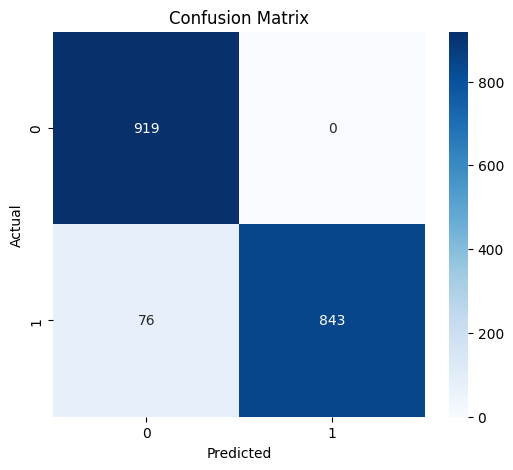


Top 10 Important Features:
                feature  importance
37             cylinder    0.417872
42          ncap_rating    0.120162
35              airbags    0.108342
28          region_code    0.045459
32          vehicle_age    0.044472
39               length    0.036937
33         customer_age    0.034679
34       region_density    0.030807
31  subscription_length    0.024912
36         displacement    0.023887


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================
# 1. CREATE DUMMY DATA (Similar to your dataset)
# =============================================
np.random.seed(42)

n_samples = 5000

data = {
    'subscription_length': np.random.randint(1, 37, n_samples),
    'vehicle_age': np.random.randint(0, 15, n_samples),
    'customer_age': np.random.randint(21, 75, n_samples),
    'region_code': np.random.choice(range(1, 23), n_samples),
    'region_density': np.random.randint(1000, 50000, n_samples),
    'airbags': np.random.randint(0, 7, n_samples),
    'displacement': np.random.randint(800, 3000, n_samples),
    'cylinder': np.random.choice([3, 4, 6], n_samples),
    'fuel_type': np.random.choice(['Petrol', 'Diesel', 'CNG'], n_samples),
    'transmission_type': np.random.choice(['Manual', 'Automatic'], n_samples),
    'rear_brakes_type': np.random.choice(['Disc', 'Drum'], n_samples),
    'steering_type': np.random.choice(['Power', 'Electric', 'Manual'], n_samples),
    'segment': np.random.choice(['A', 'B', 'C', 'Utility', 'D', 'E'], n_samples),
    'model': np.random.choice(['Model_'+str(i) for i in range(1,12)], n_samples),
    'engine_type': np.random.choice(['Engine_'+str(i) for i in range(1,12)], n_samples),
    
    # Binary features (Yes/No)
    'is_esc': np.random.choice(['Yes', 'No'], n_samples, p=[0.7, 0.3]),
    'is_adjustable_steering': np.random.choice(['Yes', 'No'], n_samples, p=[0.6, 0.4]),
    'is_tpms': np.random.choice(['Yes', 'No'], n_samples, p=[0.5, 0.5]),
    'is_parking_sensors': np.random.choice(['Yes', 'No'], n_samples),
    'is_parking_camera': np.random.choice(['Yes', 'No'], n_samples),
    'is_front_fog_lights': np.random.choice(['Yes', 'No'], n_samples),
    'is_rear_window_wiper': np.random.choice(['Yes', 'No'], n_samples),
    'is_rear_window_washer': np.random.choice(['Yes', 'No'], n_samples),
    'is_rear_window_defogger': np.random.choice(['Yes', 'No'], n_samples),
    'is_brake_assist': np.random.choice(['Yes', 'No'], n_samples),
    'is_power_door_locks': np.random.choice(['Yes', 'No'], n_samples),
    'is_central_locking': np.random.choice(['Yes', 'No'], n_samples),
    'is_power_steering': np.random.choice(['Yes', 'No'], n_samples, p=[0.9, 0.1]),
    'is_driver_seat_height_adjustable': np.random.choice(['Yes', 'No'], n_samples),
    'is_day_night_rear_view_mirror': np.random.choice(['Yes', 'No'], n_samples),
    'is_ecw': np.random.choice(['Yes', 'No'], n_samples),
    'is_speed_alert': np.random.choice(['Yes', 'No'], n_samples, p=[0.8, 0.2]),
    
    # Numerical features for torque/power extraction simulation
    'max_torque': np.random.choice(['200Nm@1800rpm', '250Nm@2500rpm', '180Nm@1500rpm', '300Nm@2000rpm'], n_samples),
    'max_power': np.random.choice(['120bhp@4000rpm', '150bhp@3500rpm', '100bhp@5000rpm', '180bhp@3800rpm'], n_samples),
    
    'turning_radius': np.round(np.random.uniform(4.5, 6.0, n_samples), 2),
    'length': np.random.randint(3500, 5200, n_samples),
    'width': np.random.randint(1600, 2000, n_samples),
    'gross_weight': np.random.randint(1200, 2500, n_samples),
    'ncap_rating': np.random.randint(0, 6, n_samples),
    
    # Target - Imbalanced (as in your original data)
    'claim_status': np.random.choice([0, 1], n_samples, p=[0.92, 0.08])
}

df = pd.DataFrame(data)

print("Original Shape:", df.shape)
print("Original Claim Status Distribution:")
print(df['claim_status'].value_counts())

# =============================================
# 2. Your Balancing Function (Probabilistic)
# =============================================
def balance_class_probabilistic(df, target_col='claim_status'):
    df = df.copy()
    df_0 = df[df[target_col] == 0]
    df_1 = df[df[target_col] == 1]
    
    n_to_generate = len(df_0) - len(df_1)
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove(target_col)
    
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    
    # Numeric: Multivariate Gaussian
    mean = df_1[numeric_cols].mean().values
    cov = np.cov(df_1[numeric_cols].values.T)
    synthetic_numeric = np.random.multivariate_normal(mean, cov, n_to_generate)
    synthetic_numeric = pd.DataFrame(synthetic_numeric, columns=numeric_cols).clip(lower=0)
    
    # Categorical: Probabilistic sampling
    synthetic_categorical = pd.DataFrame()
    for col in categorical_cols:
        probs = df_1[col].value_counts(normalize=True)
        synthetic_categorical[col] = np.random.choice(probs.index, size=n_to_generate, p=probs.values)
    
    synthetic_df = pd.concat([synthetic_numeric, synthetic_categorical], axis=1)
    synthetic_df[target_col] = 1
    synthetic_df = synthetic_df[df.columns]
    
    df_balanced = pd.concat([df, synthetic_df], axis=0).reset_index(drop=True)
    return df_balanced, synthetic_df

df_balanced, synthetic = balance_class_probabilistic(df)
print("\nAfter Probabilistic Balancing:")
print(df_balanced['claim_status'].value_counts())

# =============================================
# 3. Preprocessing + Feature Engineering
# =============================================
# 3. Preprocessing + Feature Engineering (Fixed)
def preprocess_data(df):
    df = df.copy()
    df['torque_nm'] = df['max_torque'].str.extract(r'(\d+\.?\d*)Nm').astype(float)
    df['torque_rpm'] = df['max_torque'].str.extract(r'@(\d+)rpm').astype(float)
    df['power_bhp'] = df['max_power'].str.extract(r'(\d+\.?\d*)bhp').astype(float)
    df['power_rpm'] = df['max_power'].str.extract(r'@(\d+)rpm').astype(float)
    df.drop(['max_torque', 'max_power'], axis=1, inplace=True, errors='ignore')
    return df

def feature_eng(df):
    df = df.copy()
    df['power_to_weight'] = df['power_bhp'] / df['gross_weight']
    df['torque_per_liter'] = df['torque_nm'] / (df['displacement'] / 1000 + 1e-6)  # small epsilon safety
    df['rpm_diff'] = df['power_rpm'] - df['torque_rpm']
    
    # Fix inf / NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    numeric_new = ['power_to_weight', 'torque_per_liter', 'rpm_diff']
    for col in numeric_new:
        if df[col].isna().any():
            df[col].fillna(df[col].median(), inplace=True)
    
    # Cap unrealistic values
    df['power_to_weight'] = df['power_to_weight'].clip(0, 1.0)
    df['torque_per_liter'] = df['torque_per_liter'].clip(0, 500)
    
    return df

# Apply
df_balanced = preprocess_data(df_balanced)
df_balanced = feature_eng(df_balanced)

print("After fixed feature engineering:")
print("NaNs in new features:", df_balanced[['power_to_weight', 'torque_per_liter', 'rpm_diff']].isnull().sum().sum())
print("Inf values:", np.isinf(df_balanced[['power_to_weight', 'torque_per_liter', 'rpm_diff']]).sum().sum())

# =============================================
# 4. Encoding Pipeline (Your Strategy)
# =============================================
binary_cols = [
    'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
    'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper',
    'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
    'is_power_door_locks', 'is_central_locking', 'is_power_steering',
    'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
    'is_ecw', 'is_speed_alert'
]

ohe_cols = ['fuel_type', 'transmission_type', 'rear_brakes_type', 'steering_type', 'segment']
oe_cols = ['region_code', 'model', 'engine_type']

num_cols = [
    'subscription_length', 'vehicle_age', 'customer_age', 'region_density',
    'airbags', 'displacement', 'cylinder', 'turning_radius', 'length',
    'width', 'gross_weight', 'ncap_rating', 'torque_nm', 'torque_rpm',
    'power_bhp', 'power_rpm', 'power_to_weight', 'torque_per_liter', 'rpm_diff'
]

class BinaryMapper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            X[col] = X[col].map({'Yes': 1, 'No': 0})
        return X

preprocessor = ColumnTransformer(
    transformers=[
        ('binary', BinaryMapper(), binary_cols),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ohe_cols),
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), oe_cols),
        ('numeric', StandardScaler(), num_cols)
    ],
    remainder='drop'
)

# =============================================
# 5. Train-Test Split + Full Pipeline
# =============================================
X = df_balanced.drop(columns=['claim_status'])
y = df_balanced['claim_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

print("\nTraining the model...")
full_pipeline.fit(X_train, y_train)

# =============================================
# 6. Evaluation
# =============================================
y_pred = full_pipeline.predict(X_test)
y_pred_proba = full_pipeline.predict_proba(X_test)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance
importances = full_pipeline.named_steps['classifier'].feature_importances_
feature_names = (
    binary_cols +
    list(full_pipeline.named_steps['preprocessor'].named_transformers_['onehot'].get_feature_names_out(ohe_cols)) +
    oe_cols +
    num_cols
)

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
print("\nTop 10 Important Features:")
print(feat_imp.sort_values('importance', ascending=False).head(10))